<div style="border:4px solid red">

For all homework blocks that have numerical answers name the variable the hw plus the homework number.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import fresnel

## Fresnel Slit Diffraction

Let's look at a 1D problem.  A plane wave is incident onto a slit.  The slit transmits the electric field inside of the slit and blocks it outside of the slit as given by

$$
T(x) =
\begin{cases}
1 & |x| \le a \\
0 & \text{else}
\end{cases}
$$

Since a plane wave is incident onto the slit, the electric field just past the slit is given by 

$$
E(x,y) =
\begin{cases}
E_o & |x| \le a \\
0 & \text{else}
\end{cases}
$$

Plug this into the Fresnel diffraction integral

$E(P_0) = \frac{e^{jkz}}{j\lambda z} 
\iint_{\Sigma} E(x',y') 
\exp\left[j\frac{k}{2z}\left((x-x')^2 + (y-y')^2\right)\right]
dx' dy'$

To get

$$
E(x,y) = E_o \, \frac{e^{jkz}}{j\lambda z}
\int_{-a}^{a} \exp\left[j\frac{k}{2z}(x-x')^2\right] dx'
\int_{-\infty}^{\infty} \exp\left[j\frac{k}{2z}(y-y')^2\right] dy'
$$

$$
E(x,y) = E_o \, \frac{e^{jkz}}{j\lambda z}
\int_{-a}^{a} \exp\left[j\frac{k}{2z}(x-x')^2\right] dx'
$$

How do you solve this integral

<details open>
<summary>Click to collapse</summary>



Using Fresnel integrals:

$$
C(x) = \int_0^x \cos\left(\frac{\pi}{2} t^2\right) dt,
\quad
S(x) = \int_0^x \sin\left(\frac{\pi}{2} t^2\right) dt
$$
</details>

<div style="border:4px solid red">

**HW1:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto an infinite  slit with a width of 1mm.  Create a plot of the normalized field 100mm away from the slit with an analysis array of . What is the full width at half maximum (FWHM) in units of meter? 

HELP:  It should look like this:

<img src="fresnel_slit1.jpg" width="300">

HW1 FWHM: 2.029e-04 m


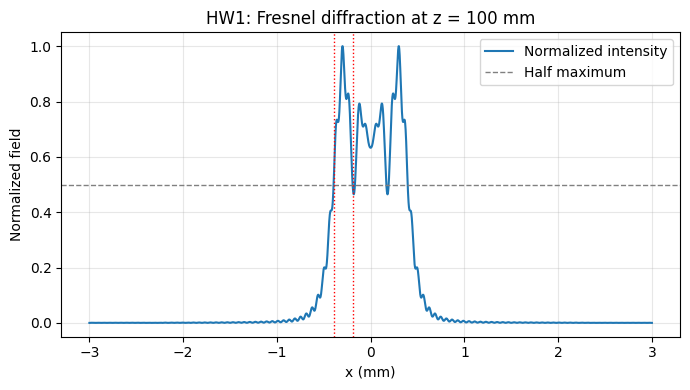

In [24]:
wavelength = 600e-9  # meters
slit_width = 1e-3  # meters
half_width = slit_width / 2
z = 100e-3  # meters
x = np.linspace(-3e-3, 3e-3, 4000)


def fresnel_slit_field(x_positions, half_width, wavelength, distance):
    scale = np.sqrt(2 / (wavelength * distance))
    u_plus = scale * (x_positions + half_width)
    u_minus = scale * (x_positions - half_width)
    c_plus, s_plus = fresnel(u_plus)
    c_minus, s_minus = fresnel(u_minus)
    return (c_plus - c_minus) + 1j * (s_plus - s_minus)


def fwhm_with_bounds(x_positions, values):
    peak_idx = np.argmax(values)
    half_max = 0.5 * values[peak_idx]

    def _interp(x1, y1, x2, y2):
        if y2 == y1:
            return x1
        return x1 + (half_max - y1) * (x2 - x1) / (y2 - y1)

    left = right = None
    for idx in range(peak_idx, 0, -1):
        y_low = values[idx - 1]
        y_high = values[idx]
        if y_low <= half_max <= y_high:
            left = _interp(x_positions[idx - 1], y_low, x_positions[idx], y_high)
            break

    for idx in range(peak_idx, len(values) - 1):
        y_high = values[idx]
        y_low = values[idx + 1]
        if y_high >= half_max >= y_low:
            right = _interp(x_positions[idx], y_high, x_positions[idx + 1], y_low)
            break

    if left is None or right is None:
        return np.nan, np.nan, np.nan

    return right - left, left, right


field = fresnel_slit_field(x, half_width, wavelength, z)
intensity = np.abs(field) ** 2
normalized_intensity = intensity / intensity.max()

hw1, left_x, right_x = fwhm_with_bounds(x, normalized_intensity)

plt.figure(figsize=(7, 4))
plt.plot(x * 1e3, normalized_intensity, label="Normalized intensity")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Half maximum")
if np.isfinite(left_x):
    plt.axvline(left_x * 1e3, color="red", linestyle=":", linewidth=1)
if np.isfinite(right_x):
    plt.axvline(right_x * 1e3, color="red", linestyle=":", linewidth=1)
plt.xlabel("x (mm)")
plt.ylabel("Normalized field")
plt.title("HW1: Fresnel diffraction at z = 100 mm")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

print(f"HW1 FWHM: {hw1:.3e} m")

<div style="border:4px solid red">

**HW2:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto an infinite  slit with a width of 1mm.  Create a plot of the normalized field 10m away from the slit. What is the full width at half maximum (FWHM) in units of meter? 

HW2 FWHM: 7.244e-03 m


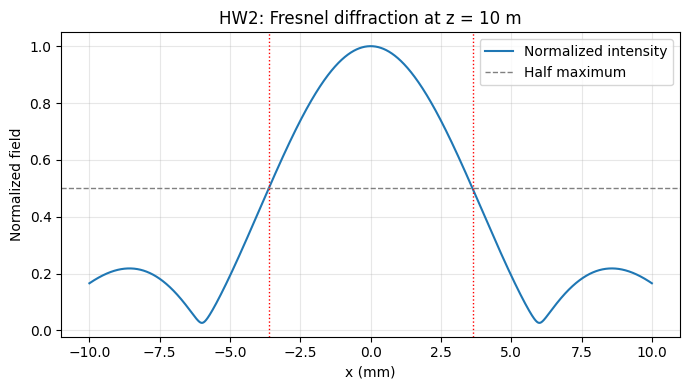

In [25]:
x = np.linspace(-10e-3, 10e-3, 4000)
z = 10

field = fresnel_slit_field(x, half_width, wavelength, z)
intensity = np.abs(field)
normalized_intensity = intensity / intensity.max()

hw2, left_x, right_x = fwhm_with_bounds(x, normalized_intensity)

plt.figure(figsize=(7, 4))
plt.plot(x * 1e3, normalized_intensity, label="Normalized intensity")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Half maximum")
if np.isfinite(left_x):
    plt.axvline(left_x * 1e3, color="red", linestyle=":", linewidth=1)
if np.isfinite(right_x):
    plt.axvline(right_x * 1e3, color="red", linestyle=":", linewidth=1)
plt.xlabel("x (mm)")
plt.ylabel("Normalized field")
plt.title("HW2: Fresnel diffraction at z = 10 m")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

print(f"HW2 FWHM: {hw2:.3e} m")

<div style="border:4px solid red">

**HW3:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto an aperture with a width of 1mm and height of 0.1mm.  Create a plot of the normalized field 1m away from the slit.  Show line plots for both directions (x and y). What is the full width at half maximum (FWHM) of the x-direction in meters? 

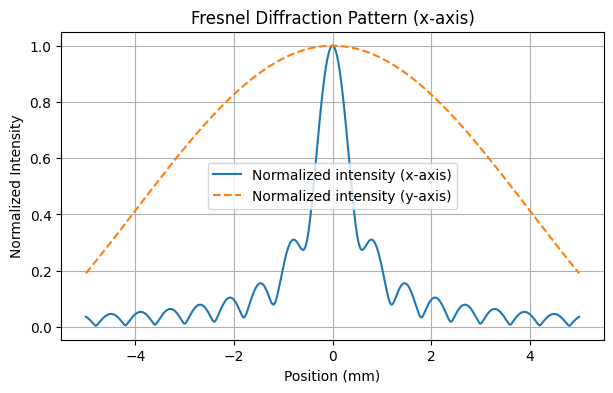

HW3 FWHM (x-axis): 7.715e-04 m
HW3 FWHM (y-axis): 7.240e-03 m


In [26]:
x = np.linspace(-5e-3, 5e-3, 4000)
y = np.linspace(-5e-3, 5e-3, 4000)
z = 1
half_width_x = 1e-3 / 2
half_width_y = 0.1e-3 / 2

field_x = fresnel_slit_field(x, half_width_x, wavelength, z)
field_y = fresnel_slit_field(y, half_width_y, wavelength, z)

intensity_x = np.abs(field_x)
intensity_y = np.abs(field_y)

normalized_intensity_x = intensity_x / intensity_x.max()
normalized_intensity_y = intensity_y / intensity_y.max()

hw3_x, left_x, right_x = fwhm_with_bounds(x, normalized_intensity_x)
hw3_y, left_y, right_y = fwhm_with_bounds(y, normalized_intensity_y)


plt.figure(figsize=(7, 4))
plt.plot(x * 1e3, normalized_intensity_x, label="Normalized intensity (x-axis)")    
plt.plot(y * 1e3, normalized_intensity_y, label="Normalized intensity (y-axis)", linestyle="--")
plt.xlabel("Position (mm)")
plt.ylabel("Normalized Intensity")
plt.title("Fresnel Diffraction Pattern (x-axis)")
plt.legend()
plt.grid(True)
plt.show()

hw3 = hw3_x
print(f"HW3 FWHM (x-axis): {hw3_x:.3e} m")
print(f"HW3 FWHM (y-axis): {hw3_y:.3e} m")

<div style="border:4px solid red">

**HW4:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto an aperture with a width of 1mm and height of 0.1mm.  Create a false color 2D image of the normalized field 1m away from the slit. The image should be square with a width of 10mm. What is the full width at half maximum (FWHM) of the y-direction in meters? 

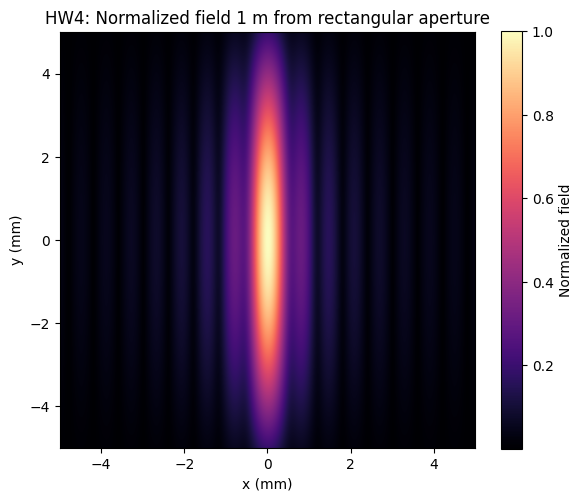

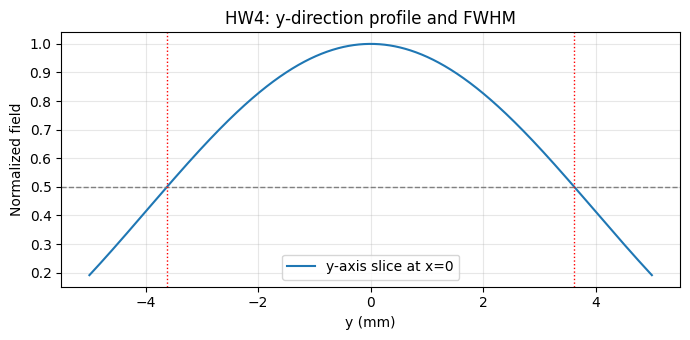

HW4 FWHM (y-direction): 7.240e-03 m


In [27]:
x = np.linspace(-5e-3, 5e-3, 1201)
y = np.linspace(-5e-3, 5e-3, 1201)
z = 1
half_width_x = 1e-3 / 2
half_width_y = 0.1e-3 / 2

field_x = fresnel_slit_field(x, half_width_x, wavelength, z)
field_y = fresnel_slit_field(y, half_width_y, wavelength, z)
field_2d = np.outer(field_y, field_x)

intensity_2d = np.abs(field_2d)
normalized_intensity_2d = intensity_2d / intensity_2d.max()

center_idx = len(x) // 2
line_y = normalized_intensity_2d[:, center_idx]
hw4, left_y, right_y = fwhm_with_bounds(y, line_y)

plt.figure(figsize=(6, 5))
plt.imshow(
    normalized_intensity_2d,
    extent=(-5, 5, -5, 5),
    origin="lower",
    cmap="magma",
    aspect="equal",
)
plt.colorbar(label="Normalized field")
plt.title("HW4: Normalized field 1 m from rectangular aperture")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.5))
plt.plot(y * 1e3, line_y, label="y-axis slice at x=0")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
if np.isfinite(left_y):
    plt.axvline(left_y * 1e3, color="red", linestyle=":", linewidth=1)
if np.isfinite(right_y):
    plt.axvline(right_y * 1e3, color="red", linestyle=":", linewidth=1)
plt.xlabel("y (mm)")
plt.ylabel("Normalized field")
plt.title("HW4: y-direction profile and FWHM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"HW4 FWHM (y-direction): {hw4:.3e} m")

<div style="border:4px solid red">

**HW5:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto a set of two square apertures.  Each aperture has a width of 1mm and they are separated in the x-direction with a gap of 1mm.  Create a false color 2D image of the normalized field 1m away from the slit. The image should be square with a width of 10mm. Create a x-direction line plot with 1000 points from $-5mm < x <5mm$.  (np.linspace(-5e-3, 5e-3, 1000) Name the linear x-direction nbormalized intensity plot as hw5.

<img src="double.jpg" width="300">

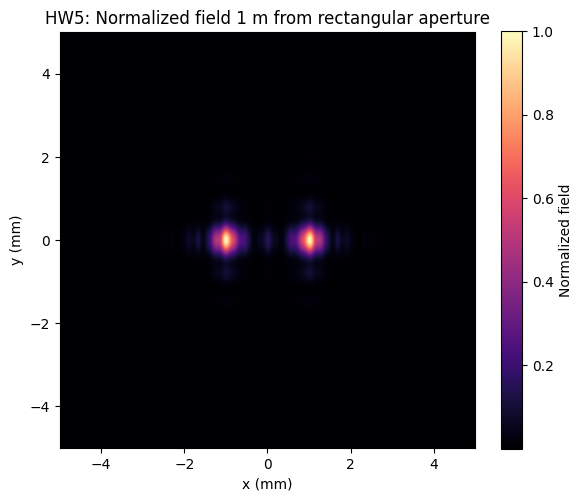

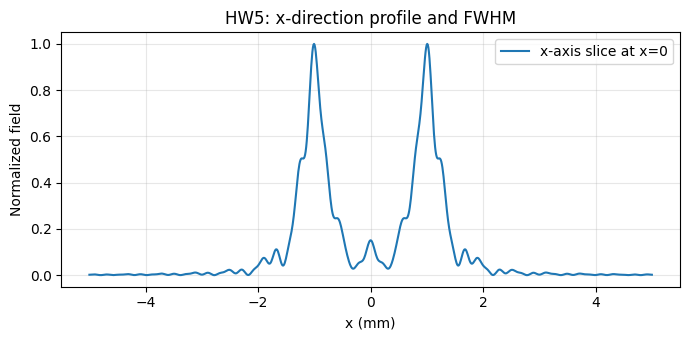

In [28]:
x = np.linspace(-5e-3, 5e-3, 1000)
y = np.linspace(-5e-3, 5e-3, 1000)
z = 1
half_width_x = 1e-3 / 2
slit_spacing_x = 1e-3
half_width_y = 1e-3 / 2

field_x = fresnel_slit_field(x - slit_spacing_x / 2 - half_width_x, half_width_x, wavelength, z)
field_x += fresnel_slit_field(x + slit_spacing_x / 2 + half_width_x, half_width_x, wavelength, z)
field_y = fresnel_slit_field(y, half_width_y, wavelength, z)

intensity_x = np.abs(field_x) ** 2
normalized_intensity_x = intensity_x / intensity_x.max()

field_2d = np.outer(field_y, field_x)
intensity_2d = np.abs(field_2d) ** 2
normalized_intensity_2d = intensity_2d / intensity_2d.max()
hw5 = normalized_intensity_x


plt.figure(figsize=(6, 5))
plt.imshow(
    normalized_intensity_2d,
    extent=(-5, 5, -5, 5),
    origin="lower",
    cmap="magma",
    aspect="equal",
)
plt.colorbar(label="Normalized field")
plt.title("HW5: Normalized field 1 m from rectangular aperture")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.5))
plt.plot(x * 1e3, normalized_intensity_x, label="x-axis slice at x=0")
plt.xlabel("x (mm)")
plt.ylabel("Normalized field")
plt.title("HW5: x-direction profile and FWHM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="border:4px solid red">

**HW6:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto a set of two square apertures.  Each aperture has a width of 1mm and they are separated in the x-direction with a gap of 1mm.  Create a false color 2D image of the normalized field 20m away from the slit. The image should be square with a width of 10mm. Create a x-direction line plot with 1000 points from $-10mm < x <10mm$.  (np.linspace(-10e-3, 10e-3, 1000) Name the linear x-direction nbormalized intensity plot as hw6.

<img src="double.jpg" width="300">

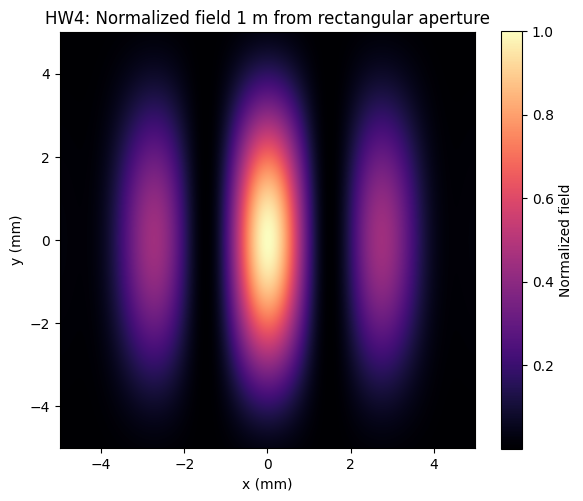

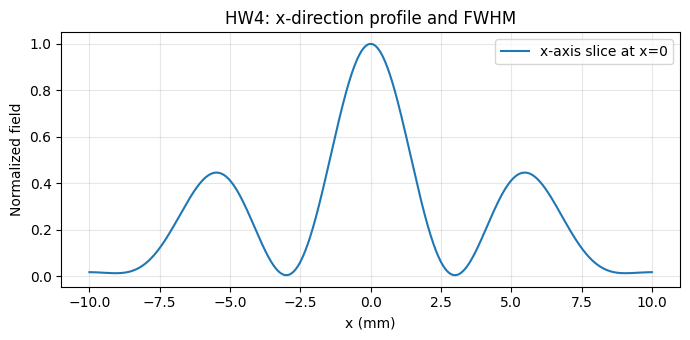

In [29]:
x = np.linspace(-10e-3, 10e-3, 1000)
y = np.linspace(-10e-3, 10e-3, 1000)
z = 20
half_width_x = 1e-3 / 2
slit_spacing_x = 1e-3
half_width_y = 1e-3 / 2

field_x = fresnel_slit_field(x - slit_spacing_x / 2 - half_width_x, half_width_x, wavelength, z)
field_x += fresnel_slit_field(x + slit_spacing_x / 2 + half_width_x, half_width_x, wavelength, z)
field_y = fresnel_slit_field(y, half_width_y, wavelength, z)

intensity_x = np.abs(field_x) ** 2
normalized_intensity_x = intensity_x / intensity_x.max()

field_2d = np.outer(field_y, field_x)
intensity_2d = np.abs(field_2d) ** 2
normalized_intensity_2d = intensity_2d / intensity_2d.max()
hw6 = normalized_intensity_x


plt.figure(figsize=(6, 5))
plt.imshow(
    normalized_intensity_2d,
    extent=(-5, 5, -5, 5),
    origin="lower",
    cmap="magma",
    aspect="equal",
)
plt.colorbar(label="Normalized field")
plt.title("HW4: Normalized field 1 m from rectangular aperture")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.5))
plt.plot(x * 1e3, normalized_intensity_x, label="x-axis slice at x=0")
plt.xlabel("x (mm)")
plt.ylabel("Normalized field")
plt.title("HW4: x-direction profile and FWHM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="border:4px solid red">

**HW7:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto an ideal lens with a focal length of $f=50mm$ and an aperture with a diameter of $D=20mm$.  What is the FWHM at a distance of 40mm away from the lens in units of meter?

As a check here is the profile of the beam a distance of 45mm away from the lens.

<img src="fresnel_lens.png" width="400">

## Lens Phase Transformation

A lens adds a phase transformation.  The total phase delay caused by the lens is

$ \phi(x,y) = k n \,\Delta(x,y) + k \left(\Delta_o - \Delta(x,y) \right)$

The lens transmission becomes

$ T_{\text{lens}} = e^{j \phi}=\exp \left(j k \Delta_o \right) \,\exp \left[ j k (n-1) \Delta(x,y) \right]$

**Thickness Function,  $\Delta(x,y)$**

Separate the lens into three parts

<img src="lens.jpg" width="500">

The thickness of the front curved portion of the lens is $\Delta_{01}$, the edge thickness of the lens is $\Delta_{02}$, and the back curved portion is $\Delta_{03}$.  The center thickness of the lens is $d_{lens}=\Delta_{01}+\Delta_{02}+\Delta_{02}$.

$h$ is the height from the center of the lens and is given by $\sqrt{x^2+y^2}$.

Part (1): The thickness of the front glass surface is 

$\Delta_1(x,y) = \Delta_{01}-\left(R_1 -\sqrt{R_1^2 - (x^2+y^2)} \right)$

factor out $R_1$ to get 

$\Delta_1(x,y) = \Delta_{01} - R_1 \left(1 -\sqrt{1 - \frac{(x^2+y^2)}{R_1^2}} \right)$


Part (2): The lens edge thickness is

$\Delta_2(x,y,)=\Delta_{02}$

Part (3): The lens back surface is

$ \Delta_3(x,y) = \Delta_{03} - \left(R_2 - \sqrt{R_2^2 - (x^2+y^2)}\right)$

factor out $R_2$ to get 

$\Delta_3(x,y) = \Delta_{03} - R_2 \left(1 -\sqrt{1 - \frac{(x^2+y^2)}{R_2^2}} \right)$

The total glass thickness is 

$ \Delta(x,y) = \Delta_1+\Delta_2+\Delta_3$

$=\Delta_{01} - R_1 \left(1 -\sqrt{1 - \frac{(x^2+y^2)}{R_1^2}} \right) +
\Delta_{02} +
\Delta_{03} - R_2 \left(1 -\sqrt{1 - \frac{(x^2+y^2)}{R_2^2}} \right)$

$=d_{lens} - R_1 \left(1 -\sqrt{1 - \frac{(x^2+y^2)}{R_1^2}} \right) - R_2 \left(1 -\sqrt{1 - \frac{(x^2+y^2)}{R_2^2}} \right)$

We are dealing with perfect lenses, which means that we use the paraxial approximation $\left( x^2+y^2 \ll R_1 \right)$ and $\left( x^2+y^2 \ll R_2 \right)$.  

This means that we can use the first two terms of a binomial expansion resulting in 

$ \sqrt{1 - \frac{x^2+y^2}{R_1^2}} \approx  1 - \frac{x^2+y^2}{2 R_1^2}$

and 

$ \sqrt{1 - \frac{x^2+y^2}{R_2^2}} \approx 1 - \frac{x^2+y^2}{2R_2^2}$

Use these to get the total glass thickness of 

$\Delta = d_{lens} - R_1 \left(1 - 1 + \frac{(x^2+y^2)}{2R_1^2} \right) - R_2 \left(1 -1 + \frac{(x^2+y^2)}{2R_2^2} \right)$

$=d_{lens} - \left(\frac{(x^2+y^2)}{2} \right) \, \left(\frac{1}{R_1} + \frac{1}{R_2} \right)$


The electric field after it travels through the lens has the same amplitude but a phase term that is the wavenumber time the phase.  The phase is the propagation through the air plus the propagation through the glass, resulting in a phase of

$\phi(x,y)= k*\left[ d_{lens}-\Delta(x,y) \right] + n*k*\left[ \Delta(x,y) \right]$

$\phi(x,y)= k*\left[ d_{lens}- d_{lens} + \left(\frac{(x^2+y^2)}{2} \right) \, \left(\frac{1}{R_1} + \frac{1}{R_2} \right) \right] + n*k*\left[ d_{lens} - \left(\frac{(x^2+y^2)}{2} \right) \, \left(\frac{1}{R_1} + \frac{1}{R_2} \right)\right]$

$\phi(x,y)= n*k*d_{lens} -(n-1)* k * \left(\frac{(x^2+y^2)}{2} \right) \, \left(\frac{1}{R_1} + \frac{1}{R_2} \right)$

The electric field immediately after the lens is given by

$E(x,y) = E_o \, \exp \left(jnkd_{lens} \right) \, \exp \left(-j(n-1) k \left(\frac{(x^2+y^2)}{2} \right) \, \left(\frac{1}{R_1} + \frac{1}{R_2} \right) \right)$

We defined 

$\frac{1}{f}=(n-1) \left( \frac{1}{R_1} +\frac{1}{R_2}\right)$

So, the electric field is given by

$E(x,y) = E_o \, \exp \left(jnkd_{lens} \right) \, \exp \left(-j\frac{k}{2f} \left( x^2+y^2 \right) \right)$

The 1D Fresnel diffraction equation becomes

$E(x,y) = \frac{e^{jkz}}{j\lambda z} \, E_o \,  e^{jnkd} \,
\int\limits_{-D/2}^{D/2}  \, \exp \left(-j\frac{k}{2f} \left( x'^2 \right) \right) \exp \left(j\frac{k}{2z}(x-x')^2 \right) dx'$



We will be plotting the normalized signal.  So, we can eliminate the amplitude and common phase of the electric field, resulting in 

$E(x,y) = \int\limits_{-D/2}^{D/2}  \, \exp \left(-j\frac{k}{2f} \left( x'^2 \right) \right) \exp \left(j\frac{k}{2z}(x-x')^2 \right) dx'$

$E(x,y) = \int\limits_{-D/2}^{D/2}  \, \exp \left(j\frac{k}{2} \left( -\frac{x'^2}{f} + \frac{(x-x')^2}{z} \right) \right) dx'$

HINT: Complete the squares and then follow the same process for a slit.

## Lens Diffraction Helper

The helper below evaluates the 1D field formed by a lens and a finite circular aperture using the Fresnel approximation.

1. Start with the lens phase term and the Fresnel propagation phase.
2. Complete the square in the exponent so the aperture integral becomes a finite Fresnel integral.
3. At focus, the quadratic phase term disappears and the field reduces to a sinc-like form.
4. Away from focus, the integral is evaluated with Fresnel C/S functions.

The returned field is then normalized and used to compute the FWHM for HW7-HW10.

HW7 FWHM: 1.962e-03 m


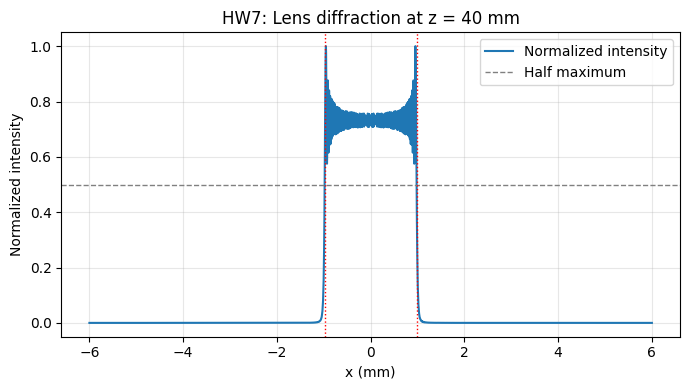

In [35]:
wavelength = 600e-9
focal_length = 50e-3
aperture_diameter = 20e-3


def fwhm_with_bounds(x_positions, values):
    peak_idx = np.argmax(values)
    half_max = 0.5 * values[peak_idx]

    def _interp(x1, y1, x2, y2):
        if y2 == y1:
            return x1
        return x1 + (half_max - y1) * (x2 - x1) / (y2 - y1)

    left = right = None
    for idx in range(peak_idx, 0, -1):
        y_low = values[idx - 1]
        y_high = values[idx]
        if y_low <= half_max <= y_high:
            left = _interp(x_positions[idx - 1], y_low, x_positions[idx], y_high)
            break

    for idx in range(peak_idx, len(values) - 1):
        y_high = values[idx]
        y_low = values[idx + 1]
        if y_high >= half_max >= y_low:
            right = _interp(x_positions[idx], y_high, x_positions[idx + 1], y_low)
            break

    if left is None or right is None:
        return np.nan, np.nan, np.nan

    return right - left, left, right


def lens_aperture_field(x_positions, wavelength, focal_length, distance, aperture_diameter):
    k = 2 * np.pi / wavelength
    half_diameter = aperture_diameter / 2

    # Fresnel propagation phase from the observation plane.
    phase_factor = np.exp(1j * k * x_positions**2 / (2 * distance))

    # Quadratic phase inside the aperture integral after completing the square.
    a = 0.5 * k * (1 / distance - 1 / focal_length)
    b = -k * x_positions / distance

    if np.isclose(a, 0.0):
        # At focus the quadratic term vanishes, so the integral reduces to a sinc-like form.
        aperture_field = np.where(
            np.isclose(b, 0.0),
            aperture_diameter,
            2 * np.sin(b * half_diameter) / b,
        )
    else:
        # Off focus, evaluate the finite-aperture Fresnel integral with Fresnel C/S terms.
        alpha = np.abs(a)
        scale = np.sqrt(2 * alpha / np.pi)
        shift = b / (2 * a)
        u1 = -half_diameter + shift
        u2 = half_diameter + shift
        t1 = scale * u1
        t2 = scale * u2
        c1, s1 = fresnel(t1)
        c2, s2 = fresnel(t2)
        fresnel_sign = 1 if a > 0 else -1
        integral = np.sqrt(np.pi / (2 * alpha)) * (
            (c2 + 1j * fresnel_sign * s2) - (c1 + 1j * fresnel_sign * s1)
        )
        aperture_field = np.exp(-1j * b**2 / (4 * a)) * integral

    return phase_factor * aperture_field


x = np.linspace(-6e-3, 6e-3, 8000)
z7 = 45e-3
field7 = lens_aperture_field(x, wavelength, focal_length, z7, aperture_diameter)
intensity7 = np.abs(field7) ** 2
normalized_intensity7 = intensity7 / intensity7.max()

hw7, left_x7, right_x7 = fwhm_with_bounds(x, normalized_intensity7)

plt.figure(figsize=(7, 4))
plt.plot(x * 1e3, normalized_intensity7, label="Normalized intensity")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Half maximum")
if np.isfinite(left_x7):
    plt.axvline(left_x7 * 1e3, color="red", linestyle=":", linewidth=1)
if np.isfinite(right_x7):
    plt.axvline(right_x7 * 1e3, color="red", linestyle=":", linewidth=1)
plt.xlabel("x (mm)")
plt.ylabel("Normalized intensity")
plt.title("HW7: Lens diffraction at z = 40 mm")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

print(f"HW7 FWHM: {hw7:.3e} m")

<div style="border:4px solid red">

**HW8:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto an ideal lens with a focal length of $f=50mm$ and an aperture with a diameter of $D=20mm$.  What is the FWHM at a distance of 50mm away from the lens in units of meter?

HW8 FWHM: 1.329e-06 m


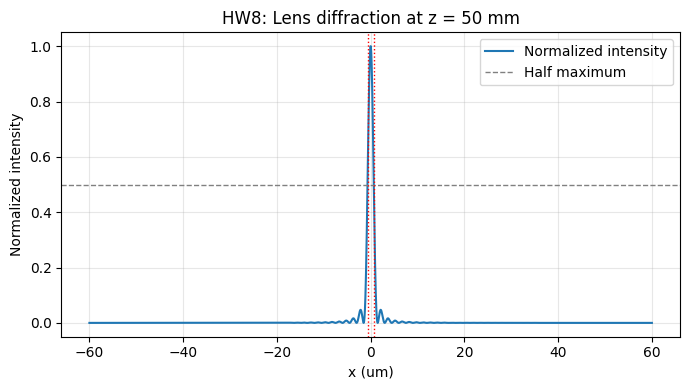

In [31]:
x = np.linspace(-60e-6, 60e-6, 5000)
z8 = 50e-3
field8 = lens_aperture_field(x, wavelength, focal_length, z8, aperture_diameter)
intensity8 = np.abs(field8) ** 2
normalized_intensity8 = intensity8 / intensity8.max()

hw8, left_x8, right_x8 = fwhm_with_bounds(x, normalized_intensity8)

plt.figure(figsize=(7, 4))
plt.plot(x * 1e6, normalized_intensity8, label="Normalized intensity")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Half maximum")
if np.isfinite(left_x8):
    plt.axvline(left_x8 * 1e6, color="red", linestyle=":", linewidth=1)
if np.isfinite(right_x8):
    plt.axvline(right_x8 * 1e6, color="red", linestyle=":", linewidth=1)
plt.xlabel("x (um)")
plt.ylabel("Normalized intensity")
plt.title("HW8: Lens diffraction at z = 50 mm")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

print(f"HW8 FWHM: {hw8:.3e} m")

<div style="border:4px solid red">

**HW9:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto an ideal lens with a focal length of $f=50mm$ and an aperture with a diameter of $D=20mm$.  What is the FWHM at a distance of 55mm away from the lens in units of meter?

HW9 FWHM: 1.957e-03 m


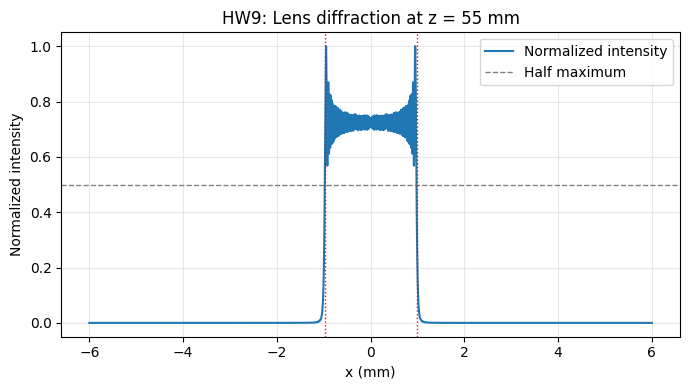

In [32]:
x = np.linspace(-6e-3, 6e-3, 8000)
z9 = 55e-3
field9 = lens_aperture_field(x, wavelength, focal_length, z9, aperture_diameter)
intensity9 = np.abs(field9) ** 2
normalized_intensity9 = intensity9 / intensity9.max()

hw9, left_x9, right_x9 = fwhm_with_bounds(x, normalized_intensity9)

plt.figure(figsize=(7, 4))
plt.plot(x * 1e3, normalized_intensity9, label="Normalized intensity")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Half maximum")
if np.isfinite(left_x9):
    plt.axvline(left_x9 * 1e3, color="red", linestyle=":", linewidth=1)
if np.isfinite(right_x9):
    plt.axvline(right_x9 * 1e3, color="red", linestyle=":", linewidth=1)
plt.xlabel("x (mm)")
plt.ylabel("Normalized intensity")
plt.title("HW9: Lens diffraction at z = 55 mm")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

print(f"HW9 FWHM: {hw9:.3e} m")

<div style="border:4px solid red">

**HW10:** A plane wave with a wavelength of $\lambda=600nm$ is incident onto an ideal lens with a focal length of $f=50mm$ and an aperture with a diameter of $D=20mm$.  Create an array that is the FWHM for 10 distances equally spread between 49.5mm and 50.5mm.  The array should be in units of meters.

HW10 FWHM array (m):
[1.86802723e-04 1.43873438e-04 1.00934450e-04 5.86639194e-05
 1.78995485e-05 1.79147100e-05 5.88186665e-05 1.01486516e-04
 1.44131071e-04 1.86593441e-04]


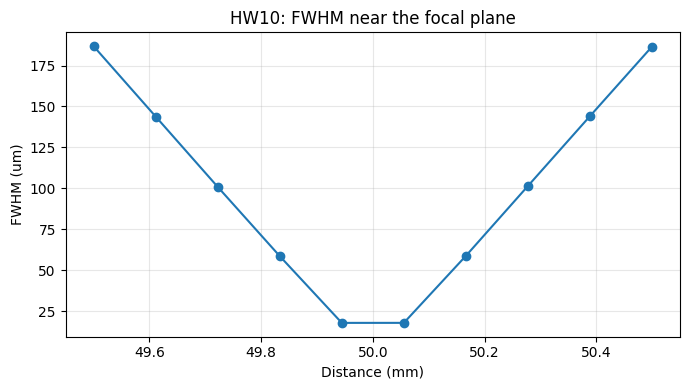

In [33]:
hw10_distances = np.linspace(49.5e-3, 50.5e-3, 10)
x = np.linspace(-6e-3, 6e-3, 12000)

hw10 = []
for distance in hw10_distances:
    field10 = lens_aperture_field(x, wavelength, focal_length, distance, aperture_diameter)
    intensity10 = np.abs(field10) ** 2
    normalized_intensity10 = intensity10 / intensity10.max()
    hw10.append(fwhm_with_bounds(x, normalized_intensity10)[0])

hw10 = np.array(hw10)

plt.figure(figsize=(7, 4))
plt.plot(hw10_distances * 1e3, hw10 * 1e6, marker="o")
plt.xlabel("Distance (mm)")
plt.ylabel("FWHM (um)")
plt.title("HW10: FWHM near the focal plane")
plt.grid(True, alpha=0.3)
plt.tight_layout()

print("HW10 FWHM array (m):")
print(hw10)